# GB regression on sequence 13 features

Minimal, readable pipeline split into cells.

In [ ]:
%pip install xgboost

import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 18
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 18




Note: you may need to restart the kernel to use updated packages.


## 1) Imports & config

In [32]:
# ---- choose model: "rf" or "hgb" ----
MODEL = "hgb"  # set to "rf" to go back

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

INFILE = "merged_output_13infile.csv"   # must contain columns: sequence, LogGFP
SEQ_COL = "sequence"
LABEL_COL = "LogGFP"
WINDOW = ("central", 5, 23)                  # ("all",0,0) or ("span", start, end)
TEST_SIZE = 0.20
SEED = 123
OUT = "seq_rf"

from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=1000,
    random_state=123
)
# hgb.fit(Xtr, ytr)  # <-- comment this until Xtr, ytr exist




The in R studion done 4 feature were computed an used for the training.

In [33]:
# ---- shape feature builder: returns X (DataFrame) ----
import re
import numpy as np
import pandas as pd

FAMILIES    = [
    "HelT",  # Helical Twist
    "MGW",   # Minor Groove Width
    "ProT",  # Propeller Twist
    "Roll",  # Roll angle
    "Rise",  # Rise per base pair step
    "Shift", # Shift
    "Slide", # Slide
    "Tilt",  # Tilt
    "Buckle",
    "Opening",
    "Shear",
    "Stagger",
    "Stretch"
]   # edit if needed
KEEP_WINDOW = (5, 23)                   # inclusive positions
EXCLUDE_IF_CONTAINS = ("rep",)          # optional substring filter

def build_X_feature(df: pd.DataFrame,
            families=FAMILIES,
            keep_window=KEEP_WINDOW,
            exclude_contains=EXCLUDE_IF_CONTAINS) -> pd.DataFrame:
    """Select MGW/ProT/Roll columns with trailing _pos index in [6..24] and return numeric DataFrame."""
    start_idx, end_idx = keep_window
    cols = []
    for c in df.columns:
        base = c.split("_")[0] if "_" in c else None
        if base not in families:
            continue
        m = re.search(r"_(\d+)$", c)
        if not m:
            continue
        pos = int(m.group(1))
        if not (start_idx <= pos <= end_idx):
            continue
        if exclude_contains and any(s in c for s in exclude_contains):
            continue
        cols.append(c)
    # numeric df (no imputation/variance here)
    return df[cols].apply(pd.to_numeric, errors="coerce")



save X_feature once for all

## 4) Train, calibrate, evaluate

In [34]:
# ---------- drop-in: clean split + weights + no-leak calibration ----------

from sklearn.model_selection import train_test_split, KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.impute import SimpleImputer
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) Load & filter
df = pd.read_csv(INFILE)

df = df[df[LABEL_COL] > 1.2].reset_index(drop=True)

# 2) Features (ensure build_X does NOT impute; we impute AFTER the split)
X = build_X_feature(df)
y = pd.to_numeric(df[LABEL_COL], errors="coerce").to_numpy()

# 3) Make 20-bin quantile strata (safe fallback if qcut errors)
def make_strata(y, Q=20):
    for q in range(Q, 5, -1):  # try 20 down to 6
        try:
            return pd.qcut(pd.Series(y), q=q, labels=False, duplicates="drop")
        except Exception:
            continue
    return None

bins = make_strata(y, Q=20)

# 4) 80/20 split (stratified if bins worked)
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED,
    stratify=bins if bins is not None else None
)
# 6) Compute sample weights (optional, for asymmetric tails)
def make_weights(y, lower_thr=1.5, upper_thr=2.5, low_w=1.5, high_w=2.0):
    """Return higher weights for low and high tails of y."""
    w = np.ones_like(y, float)
    w[y < lower_thr] *= low_w
    w[y > upper_thr] *= high_w
    return w

wtr = make_weights(ytr)


# 5) Train-only variance filter + imputer (prevents leakage)
var_mask = Xtr.var(ddof=0) > 1e-12
Xtr = Xtr.loc[:, var_mask]
Xte = Xte.loc[:, var_mask.index[var_mask]]

imp = SimpleImputer(strategy="mean")
Xtr = pd.DataFrame(imp.fit_transform(Xtr), columns=Xtr.columns, index=Xtr.index)
Xte = pd.DataFrame(imp.transform(Xte),   columns=Xte.columns, index=Xte.index)

# ---- Gradient Boosting instead of Random Forest ----
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

est = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=1000,
    random_state=SEED,
)

# fit (with weights if your sklearn version supports it)
try:
    est.fit(Xtr, ytr, sample_weight=wtr)
except TypeError:
    # older sklearn: no sample_weight support; fall back to unweighted fit
    est.fit(Xtr, ytr)

print("Train R² (HGB):", r2_score(ytr, est.predict(Xtr)))

# keep downstream variable name the same so the rest of your notebook works
rf = est




Train R² (HGB): 0.903987464271893


check 

In [35]:
# 1) See which columns you're actually using
print("X shape:", X.shape)
print("First 20 feature columns:", X.columns[:20].tolist())

# 2) Count features by DNA-shape family
FAMILIES_13 = ["HelT","MGW","ProT","Roll","Rise","Shift","Slide",
               "Tilt","Buckle","Opening","Shear","Stagger","Stretch"]

from collections import Counter
family_counts = Counter([c.split("_")[0] for c in X.columns])
print("Counts by family:", {k: family_counts.get(k, 0) for k in FAMILIES_13})


X shape: (97343, 247)
First 20 feature columns: ['MGW_5', 'MGW_6', 'MGW_7', 'MGW_8', 'MGW_9', 'MGW_10', 'MGW_11', 'MGW_12', 'MGW_13', 'MGW_14', 'MGW_15', 'MGW_16', 'MGW_17', 'MGW_18', 'MGW_19', 'MGW_20', 'MGW_21', 'MGW_22', 'MGW_23', 'ProT_5']
Counts by family: {'HelT': 19, 'MGW': 19, 'ProT': 19, 'Roll': 19, 'Rise': 19, 'Shift': 19, 'Slide': 19, 'Tilt': 19, 'Buckle': 19, 'Opening': 19, 'Shear': 19, 'Stagger': 19, 'Stretch': 19}


Beeswarm plot for hyphotesis thesting 

In [36]:
import shap
import matplotlib.pyplot as plt
import numpy as np

def make_shap_beeswarm(model, X, title, top_k=5, savepath=None):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    # If binary classifier → SHAP returns [neg_class, pos_class]
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values

    # select top-k-most-important features
    mean_abs = np.abs(shap_vals).mean(axis=0)
    idx = np.argsort(mean_abs)[::-1][:top_k]

    X_top = X.iloc[:, idx]
    shap_top = shap_vals[:, idx]

    plt.figure(figsize=(5,3.2))
    shap.summary_plot(
        shap_top,
        X_top,
        feature_names=X_top.columns.tolist(),
        max_display=top_k,
        plot_type="dot",
        show=False
    )
    plt.title(title, loc="left")
    plt.xlabel("SHAP value (impact on model output)")

    if savepath is not None:
        plt.tight_layout()
        plt.savefig(savepath, dpi=300)

    plt.show()


The aplha is for the intensity of the line in the middle smaller valures lower intesity

FileNotFoundError: [Errno 2] No such file or directory: ''

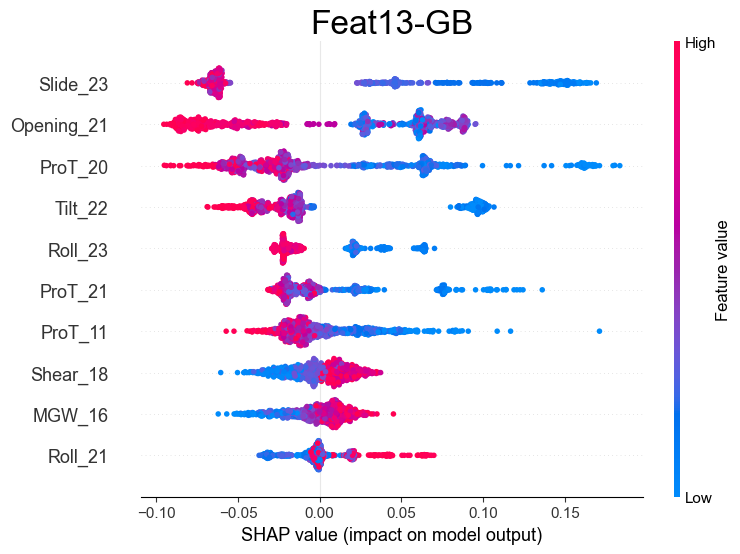

In [50]:
import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

# --- Align features to the model ---
if not isinstance(Xte, pd.DataFrame):
    Xte_df = pd.DataFrame(Xte, columns=rf.feature_names_in_)
else:
    Xte_df = Xte.copy()

Xte_df = Xte_df[rf.feature_names_in_]

# --- Subsample ---
n_sample = min(len(Xte_df), 1000)
Xte_df = Xte_df.sample(n_sample, random_state=42)

def make_shap_beeswarm_fast(model, X, title, top_k=5, savepath=None):
    explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
    shap_values = explainer.shap_values(X, approximate=True)

    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

    mean_abs = np.abs(shap_vals).mean(axis=0)
    idx = np.argsort(mean_abs)[::-1][:top_k]

    X_top = X.iloc[:, idx]
    shap_top = shap_vals[:, idx]

    plt.figure(figsize=(5, 3.2))
    shap.summary_plot(
        shap_top,
        X_top,
        feature_names=X_top.columns.tolist(),
        max_display=top_k,
        plot_type="dot",
        show=False
    )

    # soften SHAP vertical zero line
    fig = plt.gcf()
    ax = fig.axes[0]

    for line in list(ax.lines):
        xdata = line.get_xdata()
        if len(xdata) >= 2 and np.allclose(xdata, [0, 0]):
            line.remove()

    ax.axvline(0, color="lightgray", linewidth=0.8, alpha=0.5, zorder=0)

    plt.title(title, loc="center")
    plt.xlabel("SHAP value (impact on model output)")

    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.tight_layout()
        plt.gcf().savefig(savepath, dpi=600, bbox_inches="tight")

    plt.show()
    plt.close()

# --- Run + save ---
make_shap_beeswarm_fast(
    rf,
    Xte_df,
    title="Feat13-GB",
    top_k=10,
    savepath="Feat13-GB_Importance_Picture.pdf"
)


In [38]:
import os
import re
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Helper: get SHAP matrix in a robust way
# --------------------------------------------------
def get_shap_matrix(model, X):
    """
    Returns SHAP values as a 2D array: (n_samples, n_features)
    Works for many sklearn tree models.
    """
    explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
    shap_values = explainer.shap_values(X, approximate=True)

    # Binary classifier in older shap versions may return list [class0, class1]
    if isinstance(shap_values, list):
        shap_vals = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    else:
        shap_vals = shap_values

    # Sometimes shape can be (n_samples, n_features, n_outputs)
    if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 0]

    return np.asarray(shap_vals)


# --------------------------------------------------
# 2. Helper: parse feature names like Roll_23
# --------------------------------------------------
def parse_feature_name(feature_name):
    """
    Splits feature names like Roll_23 into:
    feature_type = Roll
    position = 23
    """
    m = re.match(r"^([A-Za-z]+)_(\d+)$", str(feature_name))
    if m is None:
        return None, None
    return m.group(1), int(m.group(2))


# --------------------------------------------------
# 3. Compute feature-level SHAP importance for one model
# --------------------------------------------------
def compute_feature_importance_from_shap(model, X, model_name="model", n_sample=1000, random_state=42):
    """
    Returns a dataframe with:
    model, feature, feature_type, position, mean_abs_shap
    """
    # ensure DataFrame with correct column order
    if not isinstance(X, pd.DataFrame):
        X_df = pd.DataFrame(X, columns=model.feature_names_in_)
    else:
        X_df = X.copy()

    X_df = X_df[model.feature_names_in_]

    # optional subsampling
    n_sample = min(len(X_df), n_sample)
    X_sub = X_df.sample(n_sample, random_state=random_state)

    shap_vals = get_shap_matrix(model, X_sub)
    mean_abs = np.abs(shap_vals).mean(axis=0)

    rows = []
    for feat, val in zip(X_sub.columns, mean_abs):
        feature_type, position = parse_feature_name(feat)
        rows.append({
            "model": model_name,
            "feature": feat,
            "feature_type": feature_type,
            "position": position,
            "mean_abs_shap": val
        })

    df = pd.DataFrame(rows)

    # keep only parsed positional DNA-shape features
    df = df.dropna(subset=["feature_type", "position"]).copy()
    df["position"] = df["position"].astype(int)

    return df


# --------------------------------------------------
# 4. Aggregate by position
# --------------------------------------------------
def aggregate_position_importance(feature_importance_df):
    """
    Sums feature importance across feature types at each position.
    Output columns:
    model, position, positional_importance
    """
    pos_df = (
        feature_importance_df
        .groupby(["model", "position"], as_index=False)["mean_abs_shap"]
        .sum()
        .rename(columns={"mean_abs_shap": "positional_importance"})
    )
    return pos_df


# --------------------------------------------------
# 5. Aggregate by position AND feature type (optional)
# --------------------------------------------------
def aggregate_position_featuretype_importance(feature_importance_df):
    """
    Keeps feature types separate.
    Output:
    model, feature_type, position, mean_abs_shap
    """
    out = (
        feature_importance_df
        .groupby(["model", "feature_type", "position"], as_index=False)["mean_abs_shap"]
        .sum()
    )
    return out


# --------------------------------------------------
# 6. Autocorrelation
# --------------------------------------------------
def autocorrelation(x, max_lag=None):
    """
    Normalized autocorrelation for 1D signal x.
    Returns lags and autocorrelation values.
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)

    if max_lag is None:
        max_lag = len(x) - 1

    denom = np.sum(x ** 2)
    if denom == 0:
        return np.arange(max_lag + 1), np.zeros(max_lag + 1)

    acf = [1.0]
    for lag in range(1, max_lag + 1):
        num = np.sum(x[:-lag] * x[lag:])
        acf.append(num / denom)

    return np.arange(max_lag + 1), np.array(acf)


# --------------------------------------------------
# 7. Main plotting function
# --------------------------------------------------
def plot_periodicity_summary(pos_df, title="SHAP positional periodicity", savepath=None):
    """
    Creates:
    A) line plot mean +/- SD across models
    B) heatmap of models x positions
    C) autocorrelation of mean positional importance
    """
    pivot = pos_df.pivot(index="model", columns="position", values="positional_importance")
    pivot = pivot.sort_index(axis=1)

    positions = pivot.columns.to_numpy()
    mean_imp = pivot.mean(axis=0).to_numpy()
    std_imp = pivot.std(axis=0).to_numpy()

    # autocorrelation of the mean profile
    max_lag = min(15, len(mean_imp) - 1)
    lags, acf_vals = autocorrelation(mean_imp, max_lag=max_lag)

    fig = plt.figure(figsize=(14, 4.8))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.0, 0.9])

    # ---------------- Panel A: mean positional importance
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(positions, mean_imp, marker="o", linewidth=2)
    ax1.fill_between(positions, mean_imp - std_imp, mean_imp + std_imp, alpha=0.25)
    ax1.set_xlabel("Position")
    ax1.set_ylabel("Mean summed |SHAP|")
    ax1.set_title("A. Mean positional importance across models")

    # guide lines for helix periodicity
    for p in positions:
        pass

    # mark every 5 bp relative to first position
    p0 = positions.min()
    for p in positions:
        rel = p - p0
        if rel > 0 and rel % 5 == 0:
            ax1.axvline(p, linestyle="--", linewidth=1, alpha=0.35)

    # ---------------- Panel B: heatmap
    ax2 = fig.add_subplot(gs[0, 1])
    im = ax2.imshow(pivot.values, aspect="auto", interpolation="nearest")
    ax2.set_xticks(np.arange(len(positions)))
    ax2.set_xticklabels(positions, rotation=90)
    ax2.set_yticks(np.arange(len(pivot.index)))
    ax2.set_yticklabels(pivot.index)
    ax2.set_xlabel("Position")
    ax2.set_title("B. Positional importance per model")
    cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    cbar.set_label("Summed |SHAP|")

    # ---------------- Panel C: autocorrelation
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(lags, acf_vals, marker="o", linewidth=2)
    ax3.axhline(0, color="black", linewidth=0.8)
    ax3.axvline(5, linestyle="--", linewidth=1, alpha=0.5)
    ax3.axvline(10, linestyle="--", linewidth=1, alpha=0.5)
    ax3.set_xlabel("Lag (bp)")
    ax3.set_ylabel("Autocorrelation")
    ax3.set_title("C. Autocorrelation of mean profile")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()

    if savepath is not None:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=600, bbox_inches="tight")

    plt.show()
    plt.close()


# --------------------------------------------------
# 8. Optional: plot feature-type-specific lines
# --------------------------------------------------
def plot_featuretype_profiles(pos_type_df, title="Feature-type-specific positional SHAP", savepath=None):
    """
    Plots separate lines for Roll, ProT, MGW, HelT across positions,
    averaged over models.
    """
    summary = (
        pos_type_df
        .groupby(["feature_type", "position"], as_index=False)["mean_abs_shap"]
        .mean()
    )

    fig, ax = plt.subplots(figsize=(8, 4.5))

    for ftype in sorted(summary["feature_type"].dropna().unique()):
        sub = summary[summary["feature_type"] == ftype].sort_values("position")
        ax.plot(sub["position"], sub["mean_abs_shap"], marker="o", linewidth=2, label=ftype)

    ax.set_xlabel("Position")
    ax.set_ylabel("Mean |SHAP|")
    ax.set_title(title)
    ax.legend(frameon=False)
    plt.tight_layout()

    if savepath is not None:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=600, bbox_inches="tight")

    plt.show()
    plt.close()


# --------------------------------------------------
# 9. Example usage for MULTIPLE models
# --------------------------------------------------
# Put your 8 models here
# Example:
# models = {
#     "RF_4": rf4,
#     "RF_8": rf8,
#     "RF_13": rf13,
#     "HGBR_4": hgbr4,
#     "HGBR_8": hgbr8,
#     "HGBR_13": hgbr13,
#     "XGB_4": xgb4,
#     "XGB_13": xgb13,
# }

def run_shap_periodicity_pipeline(models, Xte, outdir="Importance_Picture", n_sample=1000):
    all_feature_importance = []

    for model_name, model in models.items():
        print(f"Processing {model_name}...")
        df_imp = compute_feature_importance_from_shap(
            model=model,
            X=Xte,
            model_name=model_name,
            n_sample=n_sample,
            random_state=42
        )
        all_feature_importance.append(df_imp)

    all_feature_importance = pd.concat(all_feature_importance, ignore_index=True)

    # save raw feature-level SHAP importance
    os.makedirs(outdir, exist_ok=True)
    all_feature_importance.to_csv(os.path.join(outdir, "feature_level_shap_importance.csv"), index=False)

    # aggregate by position
    pos_df = aggregate_position_importance(all_feature_importance)
    pos_df.to_csv(os.path.join(outdir, "position_level_shap_importance.csv"), index=False)

    # aggregate by position + type
    pos_type_df = aggregate_position_featuretype_importance(all_feature_importance)
    pos_type_df.to_csv(os.path.join(outdir, "position_featuretype_shap_importance.csv"), index=False)

    # plots
    plot_periodicity_summary(
        pos_df,
        title="Helical periodicity of positional SHAP importance",
        savepath=os.path.join(outdir, "SHAP_periodicity_summary.png")
    )

    plot_featuretype_profiles(
        pos_type_df,
        title="Feature-type-specific positional SHAP profiles",
        savepath=os.path.join(outdir, "SHAP_featuretype_profiles.png")
    )

    return all_feature_importance, pos_df, pos_type_df

## 5) Plots & saving predictions

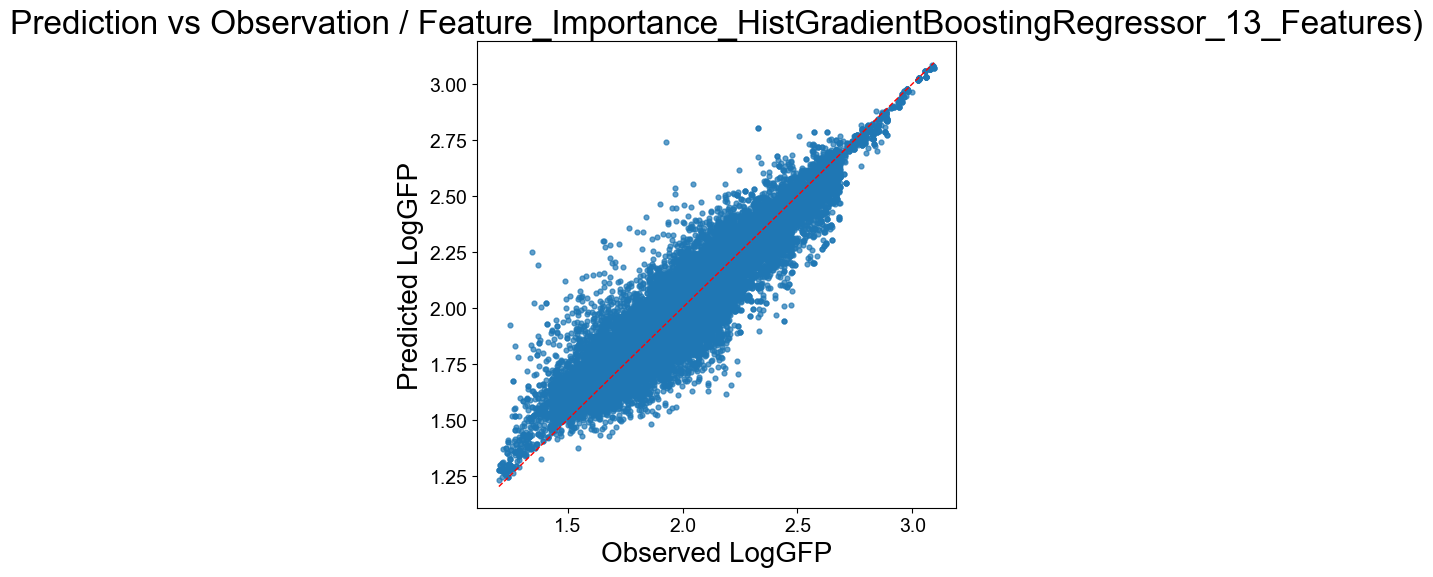

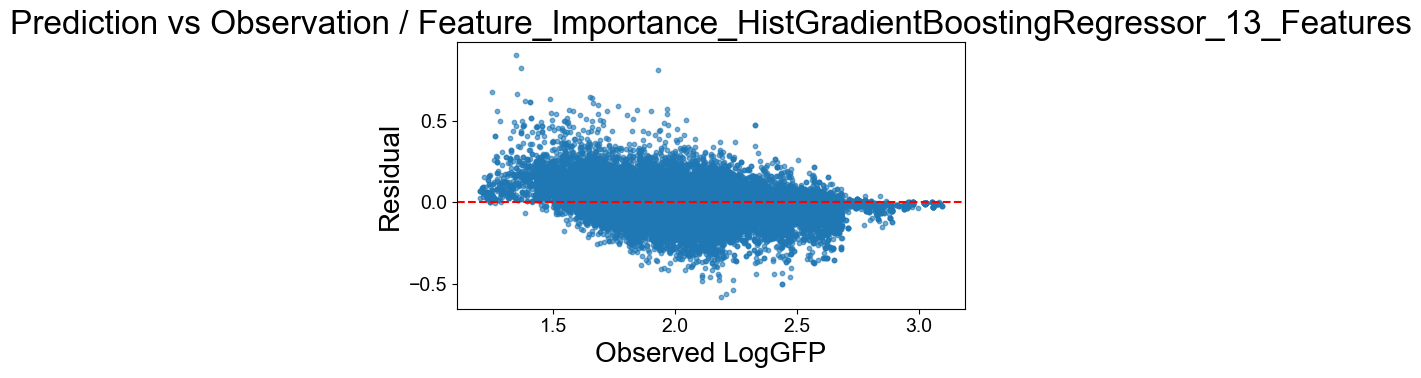

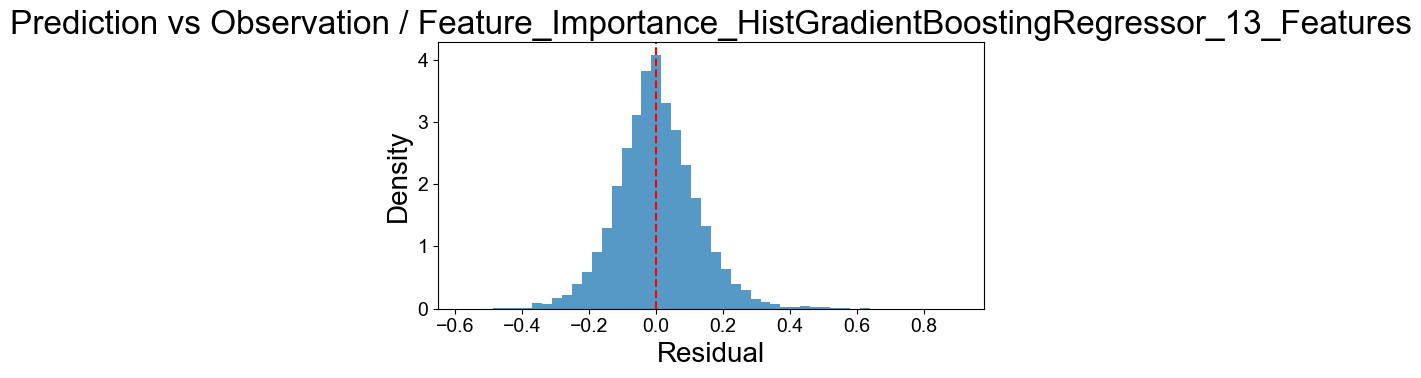

Saved: seq_rf_preds.csv
Mean residual: 0.0016016245233620924


In [39]:
# ---- Compute predictions cleanly ----
y_pred = rf.predict(Xte)          # <--- use your model here (rf / hgb / etc.)
y_pred = np.array(y_pred).ravel() # ensure 1D

# If you had a raw model output (e.g., before calibration) define it here
# Otherwise, just set it equal:
y_pred_raw = y_pred.copy()

# ---- Helper to save plots ----
def show_and_save(fig, name):
    fig.tight_layout()
    fig.savefig(f"{OUT}_{name}.png", dpi=300)
    plt.show()
    plt.close(fig)

# ---- 1. Predicted vs Observed ----
fig = plt.figure(figsize=(6,6))
plt.scatter(yte, y_pred, s=12, alpha=0.7)

lo = float(min(yte.min(), y_pred.min()))
hi = float(max(yte.max(), y_pred.max()))
plt.plot([lo,hi], [lo,hi], 'r--', lw=1)

plt.xlabel("Observed LogGFP")
plt.ylabel("Predicted LogGFP")
plt.title("Prediction vs Observation / Feature_Importance_HistGradientBoostingRegressor_13_Features)")

show_and_save(fig, "pred_vs_obs")

# ---- 2. Residuals ----
res = y_pred - yte

fig = plt.figure(figsize=(6.4,4))
plt.scatter(yte, res, s=10, alpha=0.6)
plt.axhline(0, color='r', ls='--')
plt.xlabel("Observed LogGFP")
plt.ylabel("Residual")
plt.title("Prediction vs Observation / Feature_Importance_HistGradientBoostingRegressor_13_Features")

show_and_save(fig, "residuals_vs_obs")

# ---- 3. Residual distribution ----
fig = plt.figure(figsize=(6.4,4))
plt.hist(res, bins=50, density=True, alpha=0.75)
plt.axvline(0, color='r', ls='--')
plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Prediction vs Observation / Feature_Importance_HistGradientBoostingRegressor_13_Features")

show_and_save(fig, "residual_hist")

# ---- 4. Export CSV ----
pd.DataFrame({
    "y_true": yte,
    "y_pred_raw": y_pred_raw,
    "y_pred": y_pred
}).to_csv(f"{OUT}_preds.csv", index=False)

print("Saved:", f"{OUT}_preds.csv")
bias = res.mean()
print("Mean residual:", bias)


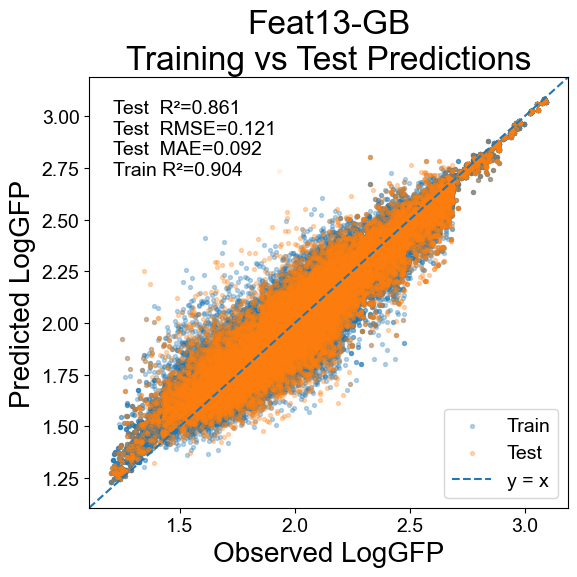

Saved figure -> rf_train_vs_test.png


In [48]:
# ---------- Plot: Training vs Test Predictions ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def plot_train_test_scatter(estimator, Xtr, ytr, Xte, yte, label_name="LogGFP",
                            title="RF — Training vs Test Predictions",
                            out_png="rf_train_vs_test.png",
                            calibrate=None):
    """
    calibrate: None (no calibration) or a fitted calibrator with .predict()
               e.g., an IsotonicRegression fitted on (yhat_tr, ytr)
    """
    # explicit, fresh preds
    yhat_tr = estimator.predict(Xtr)
    yhat_te_feature = estimator.predict(Xte)

    if calibrate is not None:
        yhat_tr = calibrate.predict(yhat_tr)
        yhat_te_feature = calibrate.predict(yhat_te)

    # metrics
    r2_tr  = r2_score(ytr, yhat_tr)
    r2_te  = r2_score(yte, yhat_te_feature)
    mae_te = mean_absolute_error(yte, yhat_te_feature)
    rmse_te = mean_squared_error(yte, yhat_te_feature) ** 0.5

    # limits
    y_all = np.concatenate([ytr, yte])
    yhat_all = np.concatenate([yhat_tr, yhat_te_feature])
    lo = float(min(y_all.min(), yhat_all.min()))
    hi = float(max(y_all.max(), yhat_all.max()))
    pad = 0.05 * (hi - lo) if hi > lo else 0.1
    lo, hi = lo - pad, hi + pad

    # plot
    plt.figure(figsize=(6, 6))
    plt.scatter(ytr, yhat_tr, s=8, alpha=0.3, label="Train")
    plt.scatter(yte, yhat_te_feature, s=8, alpha=0.3, label="Test")
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5, label="y = x")  # 45° ref

    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.xlabel(f"Observed {label_name}")
    plt.ylabel(f"Predicted {label_name}")
    plt.title(title)
    plt.legend()

    # annotate metrics (test)
    txt = f"Test  R²={r2_te:.3f}\nTest  RMSE={rmse_te:.3f}\nTest  MAE={mae_te:.3f}\nTrain R²={r2_tr:.3f}"
    plt.gca().text(0.05, 0.95, txt, transform=plt.gca().transAxes,
                   va="top", ha="left", bbox=dict(boxstyle="round", fc="white", alpha=0.7, ec="none"))

    plt.tight_layout()
    plt.savefig("Feature_Importance_HistGradientBoostingRegressor_13_Features.png", dpi=600, bbox_inches="tight")
    plt.savefig(
    "Feat13-GB— Training vs Test Predictions.pdf",
    bbox_inches="tight"
)
    plt.show()
    print(f"Saved figure -> {out_png}")

# --- use it (no calibration) ---
plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
                        title="Feat13-GB\n"
                        "Training vs Test Predictions")

# --- if you have an isotonic calibrator 'iso' fitted on (rf.predict(Xtr), ytr) ---
# plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
#                         title="RF (Calibrated) — Training vs Test Predictions",
#                         out_png="rf_train_vs_test_cal.png",
#                         calibrate=iso)


Blue points (Train): predictions on your training data (ytr vs yhat_tr)
Orange points (Test): predictions on your held-out test data (yte vs yhat)
Red dashed line: ideal line where Predicted = Observed

see the distribution

77874 19469 4.0
Middle counts 1.90–2.00: train= 9649 test= 2435


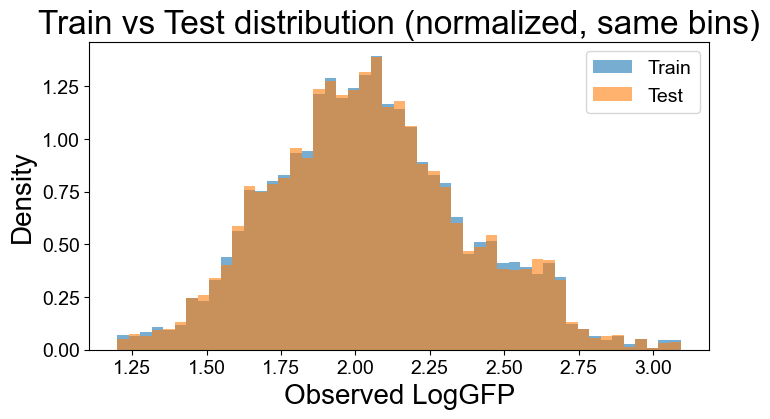

Train quantiles:
 0.0    1.201
0.1    1.640
0.2    1.766
0.3    1.870
0.4    1.951
0.5    2.031
0.6    2.105
0.7    2.197
0.8    2.314
0.9    2.506
1.0    3.094
dtype: float64

Test quantiles:
 0.0    1.201
0.1    1.640
0.2    1.766
0.3    1.870
0.4    1.950
0.5    2.031
0.6    2.106
0.7    2.197
0.8    2.313
0.9    2.505
1.0    3.094
dtype: float64


In [41]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# 1) Confirm sizes (should be ~80/20)
print(len(ytr), len(yte), round(len(ytr)/len(yte), 3))

# 2) Count samples in the “middle” band, e.g. 1.90–2.00
mid_mask_tr = (ytr >= 1.90) & (ytr <= 2.00)
mid_mask_te = (yte >= 1.90) & (yte <= 2.00)
print("Middle counts 1.90–2.00:",
      "train=", mid_mask_tr.sum(),
      "test=",  mid_mask_te.sum())

# 3) Compare shapes with SAME bins and density (so areas match)
bins = np.linspace(y.min(), y.max(), 50)
plt.figure(figsize=(8,4))
plt.hist(ytr, bins=bins, density=True, alpha=0.6, label="Train")
plt.hist(yte, bins=bins, density=True, alpha=0.6, label="Test")
plt.xlabel("Observed LogGFP"); plt.ylabel("Density")
plt.title("Train vs Test distribution (normalized, same bins)")
plt.legend(); plt.show()

# 4) Quantile table to see coverage across the range
qs = np.linspace(0,1,11)
print("Train quantiles:\n", pd.Series(ytr).quantile(qs).round(3))
print("\nTest quantiles:\n",  pd.Series(yte).quantile(qs).round(3))


In [42]:
yhat_te = rf.predict(Xte)

In [43]:
import joblib, json, time

bundle = {
    "version": "shape_rf_v1",
    "trained_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "label_col": LABEL_COL,
    "families": FAMILIES,
    "keep_window": KEEP_WINDOW,
    "exclude": EXCLUDE_IF_CONTAINS,
    "rf_params": getattr(rf, "get_params", lambda: {})(),
    "seed": SEED,
    "feature_columns": list(Xtr.columns),
    "imputer": imp,
    "calibrator": None,
    "model": rf,
  
}
bundle["y_true_te"] = yte          # true test labels
bundle["y_pred_te"] = yhat_te # the only predictions you care about



joblib.dump(bundle, "shape_booster13model.joblib")
print("Saved: shape_booster13model.joblib")

Saved: shape_booster13model.joblib


the saved model which is used for predicting expresseion levels on up element sequnces in the pCK_50 library background

In [44]:
# ===== Config =====
MODEL_PATH = "shape_booster13_model.joblib"        # <- your trained model file
NEW_FILE   = "All_Fasta_sequnes_constructed_features.csv"              # <- your input file (infile) sequnces which I want ot predict the LOgGFP
OUT_FILE   = "predictionsno_calibrated_feature.tsv"  # <- your output file (outfile)


the prediction on new sequnces not seen by the model

In [45]:
# ===== Load bundle =====
B   = joblib.load(MODEL_PATH)
rf  = B["model"]
imp = B.get("imputer", None)

# --- Always use the trained features (ignore var_mask) ---
feat_cols = list(B["feature_columns"])   # these should be your 13 trained features
keep_cols = feat_cols                    # explicitly force this

print("Expecting", len(keep_cols), "trained features:")
print(keep_cols)

# ===== Load new feature table =====
new_raw = pd.read_csv(NEW_FILE, sep=None, engine="python")

# Optional renaming for shape columns
SHAPES = ("HelT",  # Helical Twist
    "MGW",   # Minor Groove Width
    "ProT",  # Propeller Twist
    "Roll",  # Roll angle
    "Rise",  # Rise per base pair step
    "Shift", # Shift
    "Slide", # Slide
    "Tilt",  # Tilt
    "Buckle",
    "Opening",
    "Shear",
    "Stagger",
    "Stretch")

pat = re.compile(rf"^({'|'.join(map(re.escape, SHAPES))})[._]?(\d+)$")

def std_name(c):
    m = pat.match(str(c))
    if m:
        shape = m.group(1)
        idx   = int(m.group(2))   # <-- THIS removes leading zeros (01 -> 1)
        return f"{shape}_{idx}"   # gives MGW_6, ProT_7, Roll_10, ...
    return c

new = new_raw.rename(columns={c: std_name(c) for c in new_raw.columns})

# ===== Safety check =====
missing = [c for c in keep_cols if c not in new.columns]
extra   = [c for c in new.columns if c not in keep_cols]

print("Missing:", missing[:10], "…", len(missing))
print("Extra:", extra[:10], "…", len(extra))

if missing:
    raise ValueError("❌ Missing required features: " + ", ".join(missing))

# Align to the exact training feature order
Xnew = new.reindex(columns=keep_cols).apply(pd.to_numeric, errors="coerce")

# Double-check for NaNs
if np.isnan(Xnew.to_numpy()).any():
    raise ValueError("⚠️ NaN values found after alignment — check feature file!")

print("✅ All features aligned and ready for prediction.")

# ===== Predict =====
if imp is not None:
    Xnew = pd.DataFrame(imp.transform(Xnew), columns=keep_cols, index=new.index)

y_pred = rf.predict(Xnew).astype(float)
# ===== Save output (carry through sequence / ids if present) =====
out = pd.DataFrame({"prediction": y_pred}, index=new.index)

# pass through any identifying columns if they exist
passthrough_cols = [c for c in ["sequence_id", "seq_id", "sequence"] if c in new.columns]
for c in reversed(passthrough_cols):
    out.insert(0, c, new[c].values)

# optional: add a core19 column if we have sequences
if "sequence" in out.columns:
    # if your flanks are 4 nt each, keep this exact slice:
    out["core19"] = out["sequence"].astype(str).str.slice(4, -4)
    # fallback for very short strings:
    out.loc[out["core19"].isna() | (out["core19"] == ""), "core19"] = (
        out.loc[out["core19"].isna() | (out["core19"] == ""), "sequence"]
        .astype(str)
        .str.slice(0, 19)
    )
else:
    print("Note: no 'sequence' column in input -> not writing 'core19'.")

out.to_csv(OUT_FILE, sep="\t", index=False)
print(f"Saved: {OUT_FILE}  rows={len(out)}")


FileNotFoundError: [Errno 2] No such file or directory: 'shape_booster13_model.joblib'

Here that one was for figuring out waht sequnces I want to select in the lab, from a bunch of sequnces

In [ ]:
# 3) Get top 3 strongest predictions overall
top3 = out.sort_values("prediction", ascending=False).head(3)
top3["core19"] = top3["sequence"].str.slice(4, -4)  # trim flanks
top3.to_csv("predictions_top3_13_boost.tsv", sep="\t", index=False)

# 4) Get bottom 3 weakest predictions overall
bottom3 = out.sort_values("prediction", ascending=True).head(3)
bottom3["core19"] = bottom3["sequence"].str.slice(4, -4)  # trim flanks
bottom3.to_csv("predictions_bottom3_13_boost.tsv", sep="\t", index=False)

print("Also wrote:")
print(" - predictions_binned_sample3_4.tsv  (3 per bin)")
print(" - predictions_top3_13_boost.tsv            (strongest 3 overall)")
print(" - predictions_bottom3_13_boost.tsv         (weakest 3 overall)")


Also wrote:
 - predictions_binned_sample3_4.tsv  (3 per bin)
 - predictions_top3_13_boost.tsv            (strongest 3 overall)
 - predictions_bottom3_13_boost.tsv         (weakest 3 overall)


look for any sequnce in that is in the input file

In [ ]:
import pandas as pd

# Big prediction table
big = pd.read_csv("predictionsno_calibrated_feature.tsv", sep="\t")  # has core19 + prediction

# Small file with sequences you selected
small = pd.read_csv("new_sequnces.csv")  # comma-separated by default

# Merge: keep only matching sequences
merged = small.merge(
    big,
    left_on="seq",
    right_on="core19",
    how="left"
)

# Now keep only the sequence and prediction
clean = merged[["seq", "prediction"]]

print(clean)

clean.to_csv("seq_and_predictions.tsv", sep="\t", index=False)
print("Saved seq_and_predictions.tsv")


                   seq  prediction
0  GAGGACAGAATCCTACTTG         NaN
1  CGGGACCAAGGGCGGATAA         NaN
2  TAAGGCTCAGGTATAAAAG    2.817677
3  GAGAAGCAAGGTACCTAAG         NaN
4  CACGGATAGGTTGTAAAAG    2.914459
5  GATGCGTATCGGTAATATA         NaN
6  TCACGCTCTATGGAAATAA         NaN
Saved seq_and_predictions.tsv


In [ ]:
import pandas as pd

# Read as tab-separated
df = pd.read_csv("predictionsno_calibrated_feature.tsv", sep="\t")

def lookup(seq):
    print(df.loc[df["sequence"] == seq, ["sequence", "prediction"]])

lookup("AAAGGAAACAGGGTTGCACATTGGGCT")

                      sequence  prediction
2  AAAGGAAACAGGGTTGCACATTGGGCT    2.412082
